# 01 – Veri Keşfi (EDA)
### AMR Prediction | DRIAMS-A 2018

## 1. DRIAMS-A 2018 Verilerini Yükle

In [ ]:
import sys
sys.path.append("..")  # src/ modüllerine erişim

import pandas as pd
from pathlib import Path

DRIAMS_ROOT = Path("../data/driams")

# DRIAMS-A 2018 etiket dosyasını yükle
path = DRIAMS_ROOT / "DRIAMS-A" / "id" / "2018" / "2018_clean.csv"
df = pd.read_csv(path, low_memory=False)

print(f"Toplam örnek sayısı : {len(df):,}")
print(f"Toplam sütun sayısı : {df.shape[1]}")
df[["code", "species"]].head()

Toplam örnek sayısı : 30,069
Toplam sütun sayısı : 87


,code,species
0,18e02f6b-4b84-4344-9b7a-2a9cc2b5e2b6_MALDI1,Pseudomonas aeruginosa
1,e9544679-3f9d-43f6-8ce3-aac053980742_MALDI1,Candida glabrata
2,bfcad108-864f-4b37-83f3-d7dc94265213_MALDI1,Klebsiella pneumoniae
3,c649f842-5926-4bb3-8aef-d411db4241f4_MALDI1,Staphylococcus capitis
4,69eca649-ec26-4f9d-9f9a-d42aa5b9ec0f_MALDI1,Escherichia coli


## 2. Sınıf Dağılımı – Antibiyotiklere Göre R/S Oranları

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Meta sütunları çıkar, sadece antibiyotik sütunlarını al
meta_cols = {"code", "species", "laboratory_species", "Unnamed: 0", "Unnamed: 0.1"}
antibiotic_cols = [c for c in df.columns if c not in meta_cols]

# Her antibiyotik için R ve S sayısını hesapla
summary = []
for ab in antibiotic_cols:
    counts = df[ab].value_counts()
    r = counts.get("R", 0)
    s = counts.get("S", 0)
    total = r + s
    if total >= 100:  # Az örnekli antibiyotikleri atla
        summary.append({
            "antibiyotik": ab,
            "S": s,
            "R": r,
            "toplam": total,
            "R_oranı": round(r / total * 100, 1)
        })

summary_df = pd.DataFrame(summary).sort_values("toplam", ascending=False).reset_index(drop=True)
print(f"100+ etiketli antibiyotik sayısı: {len(summary_df)}")
summary_df

100+ etiketli antibiyotik sayısı: 46


,antibiyotik,S,R,toplam,R_oranı
0,Ciprofloxacin,6450,1644,8094,20.3
1,Meropenem,6787,1169,7956,14.7
2,Imipenem,6283,1417,7700,18.4
3,Piperacillin-Tazobactam,6115,1583,7698,20.6
4,Cefepime,6247,1317,7564,17.4
5,Ampicillin-Amoxicillin,1440,5926,7366,80.5
6,Cotrimoxazole,5907,1269,7176,17.7
7,Ceftriaxone,5302,1738,7040,24.7
8,Amoxicillin-Clavulanic acid,4191,2667,6858,38.9
9,Levofloxacin,4711,993,5704,17.4


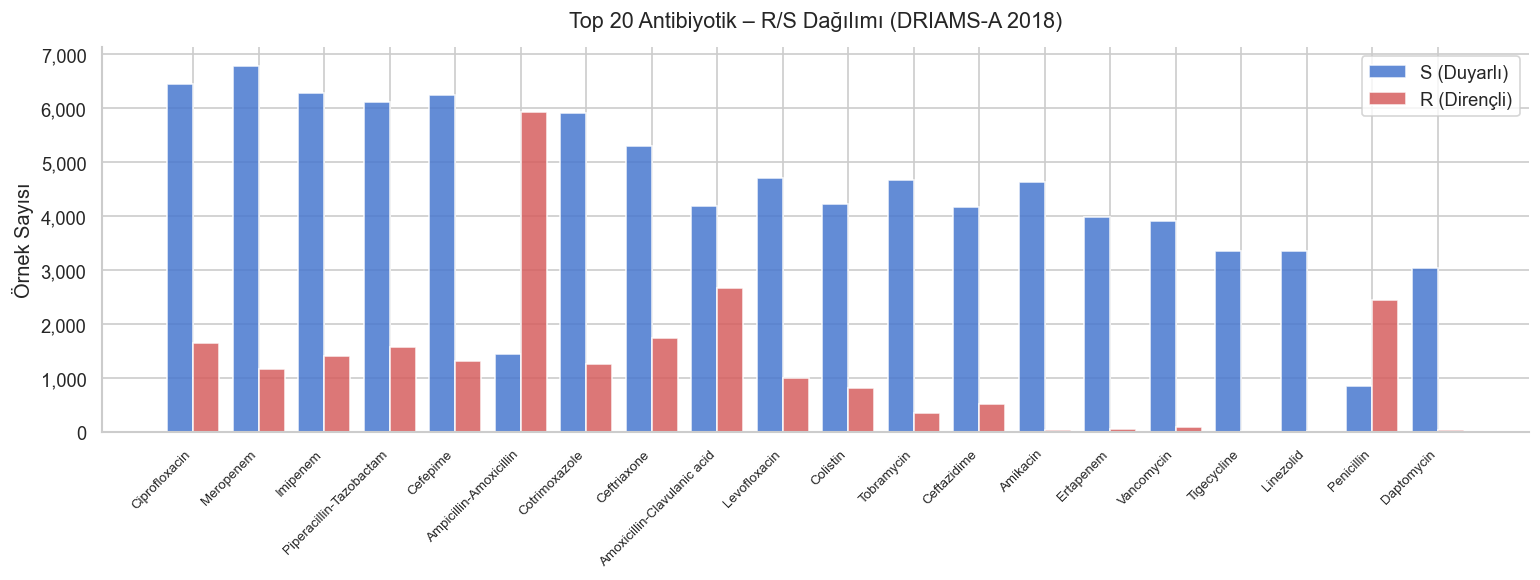

Grafik kaydedildi: outputs/figures/rs_dagilimi_top20.png


In [13]:
# En çok örneği olan 20 antibiyotiği görselleştir
top20 = summary_df.head(20).copy()
x = np.arange(len(top20))
w = 0.4

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, top20["S"], width=w, label="S (Duyarlı)",  color="#4878CF", alpha=0.85)
ax.bar(x + w/2, top20["R"], width=w, label="R (Dirençli)", color="#D65F5F", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top20["antibiyotik"], rotation=45, ha="right", fontsize=8)
ax.set_title("Top 20 Antibiyotik – R/S Dağılımı (DRIAMS-A 2018)", fontsize=13, pad=12)
ax.set_ylabel("Örnek Sayısı")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/figures/rs_dagilimi_top20.png", dpi=150)
plt.show()
print("Grafik kaydedildi: outputs/figures/rs_dagilimi_top20.png")

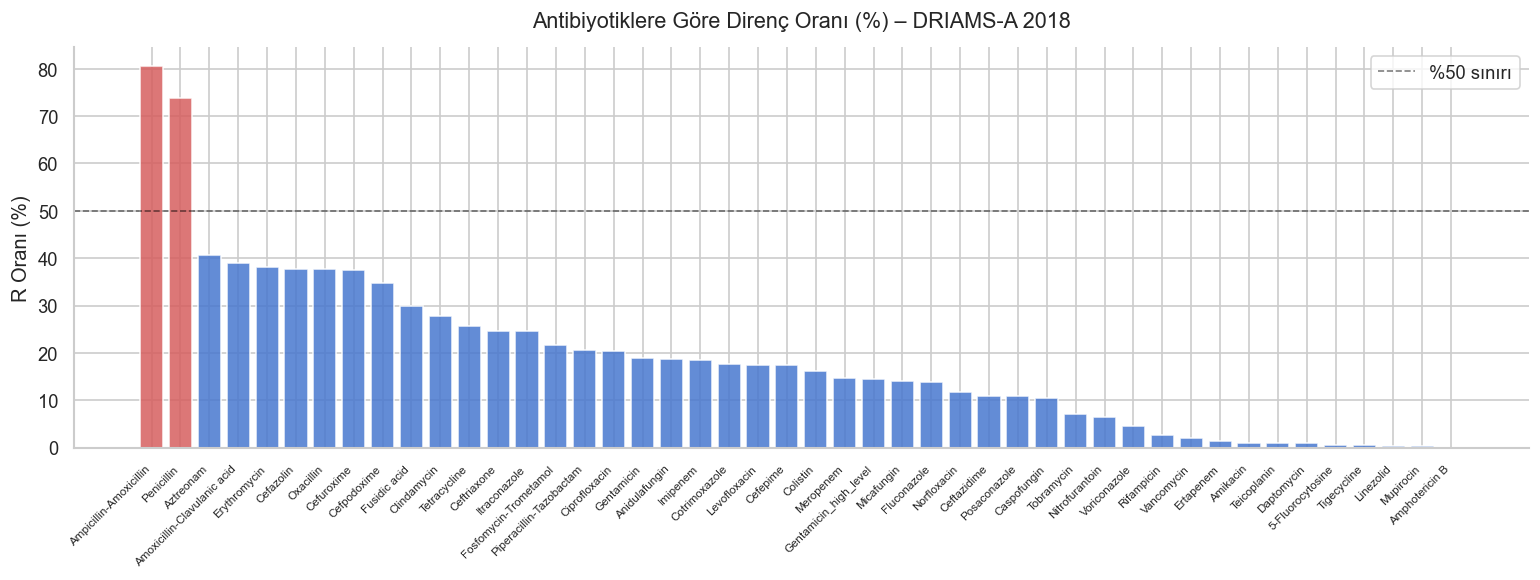

Grafik kaydedildi: outputs/figures/r_orani_antibiyotik.png


In [14]:
# R oranına göre sırala ve görselleştir
fig, ax = plt.subplots(figsize=(13, 5))
sorted_df = summary_df.sort_values("R_oranı", ascending=False)

colors = ["#D65F5F" if r >= 50 else "#4878CF" for r in sorted_df["R_oranı"]]
bars = ax.bar(range(len(sorted_df)), sorted_df["R_oranı"], color=colors, alpha=0.85, edgecolor="white")

ax.axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.5, label="%50 sınırı")
ax.set_xticks(range(len(sorted_df)))
ax.set_xticklabels(sorted_df["antibiyotik"], rotation=45, ha="right", fontsize=7)
ax.set_title("Antibiyotiklere Göre Direnç Oranı (%) – DRIAMS-A 2018", fontsize=13, pad=12)
ax.set_ylabel("R Oranı (%)")
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/figures/r_orani_antibiyotik.png", dpi=150)
plt.show()
print("Grafik kaydedildi: outputs/figures/r_orani_antibiyotik.png")

## 3. Spektrum Görselleştirmesi – Ortalama R vs S Spektrumu

Ciprofloxacin için R ve S etiketli örneklerin ortalama spektrumlarını karşılaştırıyoruz.
Model bu iki spektrum arasındaki farkı öğrenmeye çalışıyor.

In [ ]:
from src.data.load_driams import load_driams

print("Veri yükleniyor, lütfen bekleyin...")
X, y, meta = load_driams("DRIAMS-A", "2018", "Ciprofloxacin")

print(f"\n--- Veri Özeti ---")
print(f"Toplam örnek : {len(y)}")
print(f"R (dirençli) : {y.sum()} ({y.mean()*100:.1f}%)")
print(f"S (duyarlı)  : {(1-y).sum()} ({(1-y.mean())*100:.1f}%)")
print(f"X shape      : {X.shape}")

In [ ]:
# R ve S örneklerinin ortalama spektrumunu hesapla
mean_R = X[y == 1].mean(axis=0)
mean_S = X[y == 0].mean(axis=0)
diff   = mean_R - mean_S  # pozitif → R'de daha yüksek

bin_index = np.arange(6000)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Üst grafik: Ortalama spektrumlar ---
axes[0].plot(bin_index, mean_S, color="#4878CF", alpha=0.8, linewidth=0.5, label="S (Duyarlı) ortalaması")
axes[0].plot(bin_index, mean_R, color="#D65F5F", alpha=0.8, linewidth=0.5, label="R (Dirençli) ortalaması")
axes[0].set_title("Ortalama MALDI-TOF Spektrumu – R vs S (Ciprofloxacin)", fontsize=13, pad=10)
axes[0].set_ylabel("Ortalama Yoğunluk")
axes[0].legend(frameon=True)
sns.despine(ax=axes[0])

# --- Alt grafik: Fark (R - S) ---
axes[1].fill_between(bin_index, diff, 0,
                     where=(diff > 0), color="#D65F5F", alpha=0.6, label="R'de daha yüksek")
axes[1].fill_between(bin_index, diff, 0,
                     where=(diff < 0), color="#4878CF", alpha=0.6, label="S'de daha yüksek")
axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[1].set_title("Fark Spektrumu (R − S)", fontsize=13, pad=10)
axes[1].set_xlabel("Bin Index (m/z ekseni)")
axes[1].set_ylabel("Yoğunluk Farkı")
axes[1].legend(frameon=True)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig("../outputs/figures/spektrum_R_vs_S.png", dpi=150)
plt.show()
print("Grafik kaydedildi: outputs/figures/spektrum_R_vs_S.png")

In [ ]:
# En büyük farkın olduğu bin bölgelerini bul (modelin en çok dikkat etmesi gereken yerler)
import numpy as np

top_n = 10
top_bins = np.argsort(np.abs(diff))[::-1][:top_n]

print("En büyük R vs S farkının olduğu bin bölgeleri (modelin önem verdiği yerler):")
print(f"{'Bin':>6}  {'Fark':>10}  {'Yön'}")
print("-" * 30)
for b in top_bins:
    yon = "R daha yüksek" if diff[b] > 0 else "S daha yüksek"
    print(f"{b:>6}  {diff[b]:>10.6f}  {yon}")